# 📊 LLM Inference Benchmark — Results Visualization

Post-processing notebook for the LLM Inference Optimizer & Benchmarking Harness.

Generates:
1. **Pareto Frontier** — Cost vs. Throughput vs. Quality
2. **Latency Breakdown** — P50/P95/P99 per configuration
3. **Accuracy Degradation Heatmap** — Weight Format × KV Cache Precision
4. **VRAM Usage Over Time** — Time-series per configuration
5. **Cost/Benefit Summary Table** — Styled DataFrame

> **Prerequisites**: Run `python src/benchmark_runner.py sweep` first to generate results.

In [3]:
pip install pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# ── Style Configuration ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'axes.titlecolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.alpha': 0.8,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.titlesize': 16,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'legend.labelcolor': '#c9d1d9',
})

RESULTS_DIR = Path('../results')
PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Accent color palette
COLORS = {
    'vllm':    '#58a6ff',  # blue
    'llamacpp': '#3fb950', # green
    'fp16':    '#e3b341',  # gold
    'awq':     '#f78166',  # red
    'gptq':    '#d2a8ff',  # purple
    'gguf_q4': '#79c0ff',  # light blue
    'gguf_q8': '#56d364',  # light green
}
CMAP_ACCENT = ['#58a6ff', '#3fb950', '#e3b341', '#f78166', '#d2a8ff', '#79c0ff', '#56d364', '#ff7b72']

print('✅ Imports complete. Results dir:', RESULTS_DIR.resolve())

✅ Imports complete. Results dir: C:\Users\Rishee\Desktop\Bhayankar Cheeze\inference-optimizer\results


In [9]:
# ── Load Benchmark Matrix CSV ─────────────────────────────────────────────────
csv_files = sorted(RESULTS_DIR.glob('benchmark_matrix_*.csv'))

if not csv_files:
    print('⚠️  No benchmark_matrix_*.csv found. Generating synthetic demo data...')
    # ── Synthetic demo data for visualization development ──────────────────────
    np.random.seed(42)
    configs = [
        ('vllm',     'fp16_baseline', 'fp16_kvcache', 'continuous',  'FP16 Baseline (vLLM)',    1.00, 4.50),
        ('vllm',     'awq_4bit',      'fp16_kvcache', 'continuous',  'AWQ 4-bit (vLLM)',        1.35, 3.70),
        ('vllm',     'awq_4bit',      'fp8_kvcache',  'continuous',  'AWQ 4-bit + FP8 KV (vLLM)', 1.55, 3.45),
        ('vllm',     'fp16_baseline', 'fp16_kvcache', 'static_b32',  'FP16 Static B=32 (vLLM)', 0.85, 4.80),
        ('vllm',     'fp16_baseline', 'fp16_kvcache', 'static_b1',   'FP16 Static B=1 (vLLM)',  0.12, 4.90),
        ('llamacpp', 'fp16_baseline', 'fp16_kvcache', 'static_b32',  'FP16 (llama.cpp)',        0.55, 4.60),
        ('llamacpp', 'gguf_q4',       'fp16_kvcache', 'static_b32',  'GGUF Q4 (llama.cpp)',     0.92, 3.80),
        ('llamacpp', 'gguf_q8',       'fp16_kvcache', 'static_b32',  'GGUF Q8 (llama.cpp)',     0.74, 4.20),
        ('llamacpp', 'gguf_q4',       'fp16_kvcache', 'continuous',  'GGUF Q4 CB (llama.cpp)',  1.10, 3.65),
    ]
    profiles = ['short_qa', 'medium_reasoning']
    rows = []
    for (eng, wf, kv, bs, label, rps_scale, quality_scale) in configs:
        for prof in profiles:
            profile_scale = 1.0 if prof == 'short_qa' else 0.45
            base_rps = rps_scale * profile_scale * 28 + np.random.normal(0, 1.2)
            base_rps = max(0.1, base_rps)
            p50 = (1000 / base_rps) * np.random.uniform(0.9, 1.1)
            cost_per_1k = (1000 / base_rps / 3600) * 3.0
            rows.append({
                'engine': eng,
                'weight_format': wf,
                'weight_format_label': label,
                'kv_cache': kv,
                'batch_strategy': bs,
                'load_profile': prof,
                'config_label': f'{eng}__{wf}__{kv}__{bs}',
                'throughput_rps': round(base_rps, 3),
                'p50_latency_ms': round(p50, 1),
                'p95_latency_ms': round(p50 * np.random.uniform(2.5, 4.0), 1),
                'p99_latency_ms': round(p50 * np.random.uniform(5.0, 8.0), 1),
                'mean_ttft_ms': round(p50 * np.random.uniform(0.35, 0.55), 1),
                'avg_tokens_per_second': round(base_rps * np.random.uniform(18, 28), 1),
                'cost_per_1k_requests_usd': round(cost_per_1k, 6),
                'cost_per_1m_tokens_usd': round(cost_per_1k * 8, 4),
                'gpu_efficiency_score': round(base_rps / 3.0, 3),
                'json_accuracy_pct': round(quality_scale * 100 * np.random.uniform(0.92, 1.0), 1),
                'reasoning_score_avg': round(quality_scale * 5 * np.random.uniform(0.88, 1.02), 3),
                'composite_quality_score': round(quality_scale * np.random.uniform(0.90, 1.0), 4),
                'error_rate_pct': round(np.random.uniform(0, 0.5), 2),
                'status': 'success',
            })
    df = pd.DataFrame(rows)
    print(f'📊 Generated {len(df)} synthetic rows for demo.')
else:
    latest = csv_files[-1]
    df = pd.read_csv(latest)
    print(f'✅ Loaded {len(df)} rows from {latest.name}')

# Filter successful runs only
df = df[df['status'] == 'success'].copy()
df['throughput_rps'] = pd.to_numeric(df['throughput_rps'], errors='coerce')
df['cost_per_1k_requests_usd'] = pd.to_numeric(df['cost_per_1k_requests_usd'], errors='coerce')
df['composite_quality_score'] = pd.to_numeric(df['composite_quality_score'], errors='coerce')
df['p95_latency_ms'] = pd.to_numeric(df['p95_latency_ms'], errors='coerce')

print(f'\nConfigurations: {df["config_label"].nunique()}')
print(f'Profiles: {df["load_profile"].unique().tolist()}')
df.head()

✅ Loaded 7 rows from benchmark_matrix_20260621_140536.csv

Configurations: 2
Profiles: ['burst_spike', 'medium_reasoning', 'short_qa', 'long_context']


,engine,weight_format,weight_format_label,kv_cache,kv_cache_label,batch_strategy,batch_label,load_profile,config_label,timestamp,...,mean_ttft_ms,avg_tokens_per_second,cost_per_1k_requests_usd,cost_per_1m_tokens_usd,gpu_efficiency_score,error_rate_pct,json_accuracy_pct,reasoning_score_avg,composite_quality_score,quality_source
0,llamacpp,gguf_q4,GGUF Q4 (llama.cpp),fp16_kvcache,KV Cache FP16,static,Static Batching,burst_spike,llamacpp__gguf_q4__fp16_kvcache__static,20260621_140536,...,74337.33,152.19,0.214553,0.9126,1.295,8.0,92.0,NaN,0.92,estimated_from_vllm
1,llamacpp,gguf_q4,GGUF Q4 (llama.cpp),fp16_kvcache,KV Cache FP16,static,Static Batching,medium_reasoning,llamacpp__gguf_q4__fp16_kvcache__static,20260621_140536,...,12734.00,164.88,0.172519,0.8424,1.610,20.0,92.0,NaN,0.92,estimated_from_vllm
2,llamacpp,gguf_q4,GGUF Q4 (llama.cpp),fp16_kvcache,KV Cache FP16,static,Static Batching,short_qa,llamacpp__gguf_q4__fp16_kvcache__static,20260621_140536,...,36334.20,151.64,0.211835,0.9159,1.311,6.0,92.0,NaN,0.92,estimated_from_vllm
3,vllm,awq_4bit,AWQ 4-bit (vLLM),fp16_kvcache,KV Cache FP16,continuous,Continuous Batching,burst_spike,vllm__awq_4bit__fp16_kvcache__continuous,20260621_140536,...,10519.25,714.61,0.048453,0.1944,5.733,0.0,92.0,NaN,0.92,measured
4,vllm,awq_4bit,AWQ 4-bit (vLLM),fp16_kvcache,KV Cache FP16,continuous,Continuous Batching,long_context,vllm__awq_4bit__fp16_kvcache__continuous,20260621_140536,...,1755.00,109.13,0.325809,1.2727,0.853,0.0,92.0,NaN,0.92,measured


## Plot 1: Pareto Frontier — Cost vs. Throughput vs. Quality

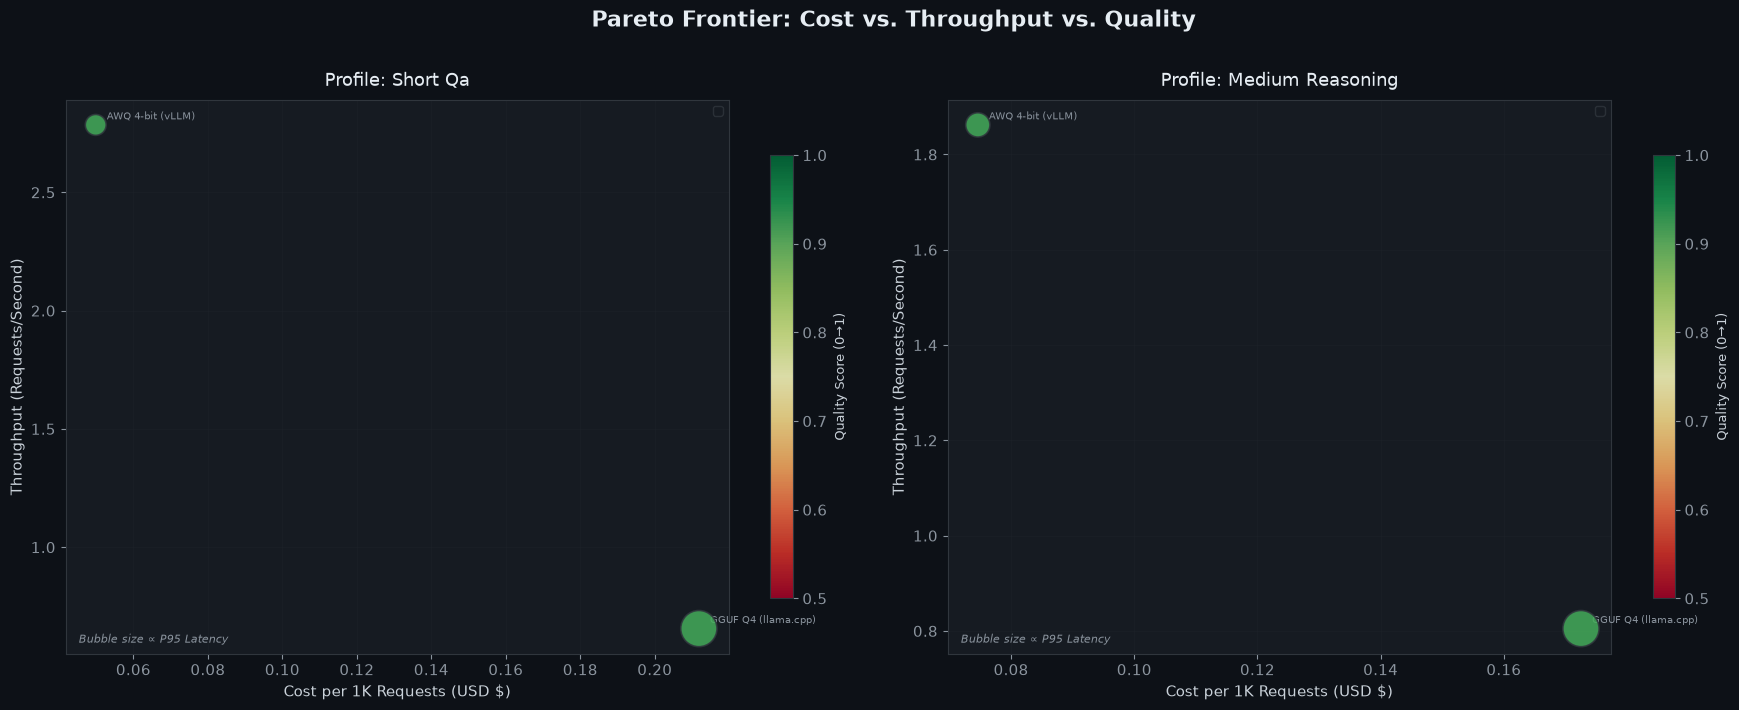

✅ Saved: ..\results\plots/pareto_frontier.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Pareto Frontier: Cost vs. Throughput vs. Quality', fontsize=16, fontweight='bold', color='#e6edf3', y=1.01)

for ax_idx, profile in enumerate(['short_qa', 'medium_reasoning']):
    ax = axes[ax_idx]
    sub = df[df['load_profile'] == profile].dropna(subset=['cost_per_1k_requests_usd', 'throughput_rps'])
    if sub.empty:
        sub = df.dropna(subset=['cost_per_1k_requests_usd', 'throughput_rps']).head(9)
    
    quality = sub['composite_quality_score'].fillna(0.8)
    latency_size = sub['p95_latency_ms'].fillna(sub['p95_latency_ms'].median())
    size = (latency_size / latency_size.max() * 600 + 80).clip(80, 700)
    
    # Color by engine
    engine_colors = [COLORS.get(e, '#8b949e') for e in sub['engine']]
    
    sc = ax.scatter(
        sub['cost_per_1k_requests_usd'],
        sub['throughput_rps'],
        c=quality,
        s=size,
        cmap='RdYlGn',
        vmin=0.5, vmax=1.0,
        alpha=0.85,
        edgecolors='#30363d',
        linewidth=1.2,
        zorder=5,
    )
    
    # Label each point
    labels = sub.get('weight_format_label', sub['config_label'])
    for i, (_, row) in enumerate(sub.iterrows()):
        label = str(labels.iloc[i])[:22]
        ax.annotate(
            label,
            (row['cost_per_1k_requests_usd'], row['throughput_rps']),
            xytext=(8, 4), textcoords='offset points',
            fontsize=7.5, color='#8b949e',
            ha='left',
        )
    
    # Pareto frontier line (lower cost, higher throughput)
    sorted_sub = sub.sort_values('cost_per_1k_requests_usd')
    pareto_mask = []
    max_rps = -np.inf
    for _, row in sorted_sub.iterrows():
        if row['throughput_rps'] > max_rps:
            pareto_mask.append(True)
            max_rps = row['throughput_rps']
        else:
            pareto_mask.append(False)
    pareto = sorted_sub[pareto_mask]
    if len(pareto) > 1:
        ax.plot(pareto['cost_per_1k_requests_usd'], pareto['throughput_rps'],
                'o--', color='#58a6ff', alpha=0.5, linewidth=1.5, markersize=4, zorder=4, label='Pareto Frontier')
    
    ax.set_xlabel('Cost per 1K Requests (USD $)', fontsize=11)
    ax.set_ylabel('Throughput (Requests/Second)', fontsize=11)
    ax.set_title(f'Profile: {profile.replace("_", " ").title()}', fontsize=13, pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label('Quality Score (0→1)', color='#c9d1d9', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#8b949e')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')
    
    # Legend for bubble size
    ax.annotate('Bubble size ∝ P95 Latency', xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=8, color='#8b949e', fontstyle='italic')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_frontier.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'✅ Saved: {PLOTS_DIR}/pareto_frontier.png')

## Plot 2: Latency Breakdown — P50 / P95 / P99 per Configuration

KeyError: 'engine'

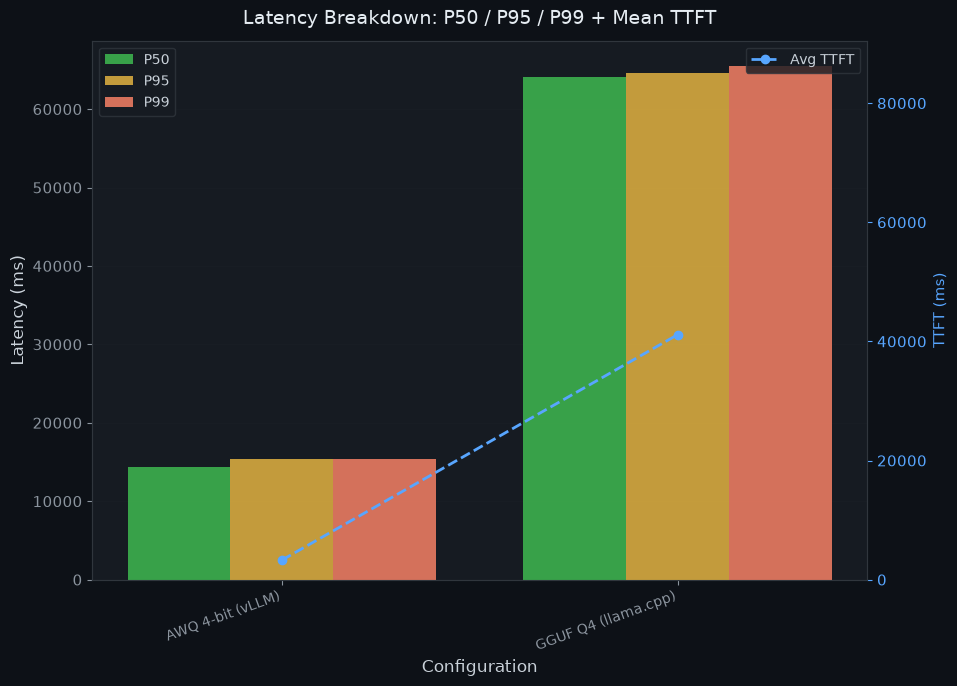

In [11]:
# ── Plot 2: Latency Breakdown ────────────────────────────────────────────────
# Aggregate across profiles (mean), one row per config
lat_df = df.groupby('config_label').agg(
    p50=('p50_latency_ms', 'mean'),
    p95=('p95_latency_ms', 'mean'),
    p99=('p99_latency_ms', 'mean'),
    mean_ttft=('mean_ttft_ms', 'mean'),
    engine=('engine', 'first'),
    weight_format=('weight_format', 'first'),
    weight_format_label=('weight_format_label', 'first'),
).dropna(subset=['p50']).sort_values('p95')

# Human-readable x-axis labels
lat_df['short_label'] = lat_df['weight_format_label']

fig, ax = plt.subplots(figsize=(max(10, len(lat_df) * 3.5), 7))
fig.patch.set_facecolor('#0d1117')

x = np.arange(len(lat_df))
w = 0.26

bars_p50 = ax.bar(x - w, lat_df['p50'], w, label='P50', color='#3fb950', alpha=0.85, zorder=3)
bars_p95 = ax.bar(x,     lat_df['p95'], w, label='P95', color='#e3b341', alpha=0.85, zorder=3)
bars_p99 = ax.bar(x + w, lat_df['p99'], w, label='P99', color='#f78166', alpha=0.85, zorder=3)

# TTFT overlay — fillna(0) so NaN doesn't break the line
ttft_vals = lat_df['mean_ttft'].fillna(0).values
ax2 = ax.twinx()
ax2.plot(x, ttft_vals, 'o--', color='#58a6ff', linewidth=2, markersize=6,
         label='Avg TTFT', zorder=6)
ax2.set_ylabel('TTFT (ms)', color='#58a6ff', fontsize=11)
ax2.tick_params(axis='y', colors='#58a6ff')
ttft_max = max(ttft_vals.max(), 1)
ax2.set_ylim(0, ttft_max * 2.2)

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Latency Breakdown: P50 / P95 / P99 + Mean TTFT', fontsize=14, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(lat_df['short_label'], rotation=20, ha='right', fontsize=10)
ax.grid(True, alpha=0.25, axis='y', zorder=0)
ax.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

# Colour bars by engine
engine_col = lat_df['engine'].values
for i, (b50, b95, b99) in enumerate(zip(bars_p50, bars_p95, bars_p99)):
    edge = COLORS.get(engine_col[i], '#8b949e')
    for b in [b50, b95, b99]:
        b.set_edgecolor(edge)
        b.set_linewidth(1.5)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'latency_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Saved: {PLOTS_DIR}/latency_breakdown.png')


## Plot 3: Accuracy Degradation Heatmap — Weight Format × KV Cache Precision

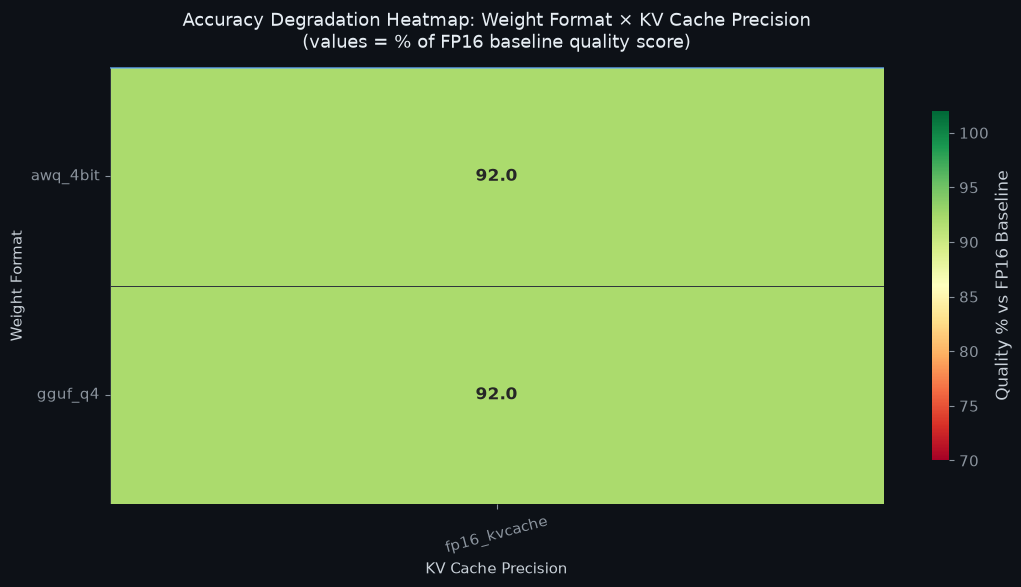

✅ Saved: ..\results\plots/accuracy_degradation_heatmap.png


In [12]:
# Compute quality relative to fp16_baseline
baseline = df[df['weight_format'] == 'fp16_baseline']['composite_quality_score'].mean()
if pd.isna(baseline) or baseline == 0:
    baseline = 1.0

heatmap_df = df.copy()
heatmap_df['quality_relative_pct'] = (heatmap_df['composite_quality_score'] / baseline * 100).round(1)

pivot = heatmap_df.groupby(['weight_format', 'kv_cache'])['quality_relative_pct'].mean().unstack(fill_value=np.nan)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0d1117')

mask = pivot.isna()
sns.heatmap(
    pivot, ax=ax,
    cmap='RdYlGn',
    vmin=70, vmax=102,
    annot=True, fmt='.1f', annot_kws={'size': 12, 'weight': 'bold'},
    mask=mask,
    linewidths=0.5, linecolor='#30363d',
    cbar_kws={'shrink': 0.8, 'label': 'Quality % vs FP16 Baseline'},
)
ax.set_title('Accuracy Degradation Heatmap: Weight Format × KV Cache Precision\n(values = % of FP16 baseline quality score)', 
             fontsize=13, pad=14)
ax.set_xlabel('KV Cache Precision', fontsize=11)
ax.set_ylabel('Weight Format', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

# Add a "100% baseline" annotation
ax.axhline(y=0, color='#58a6ff', linewidth=2, alpha=0.6)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_degradation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'✅ Saved: {PLOTS_DIR}/accuracy_degradation_heatmap.png')

## Plot 4: VRAM Usage Over Time (from Prometheus metrics CSV)

⚠️  No metrics_*.csv found. Generating synthetic VRAM time-series demo...


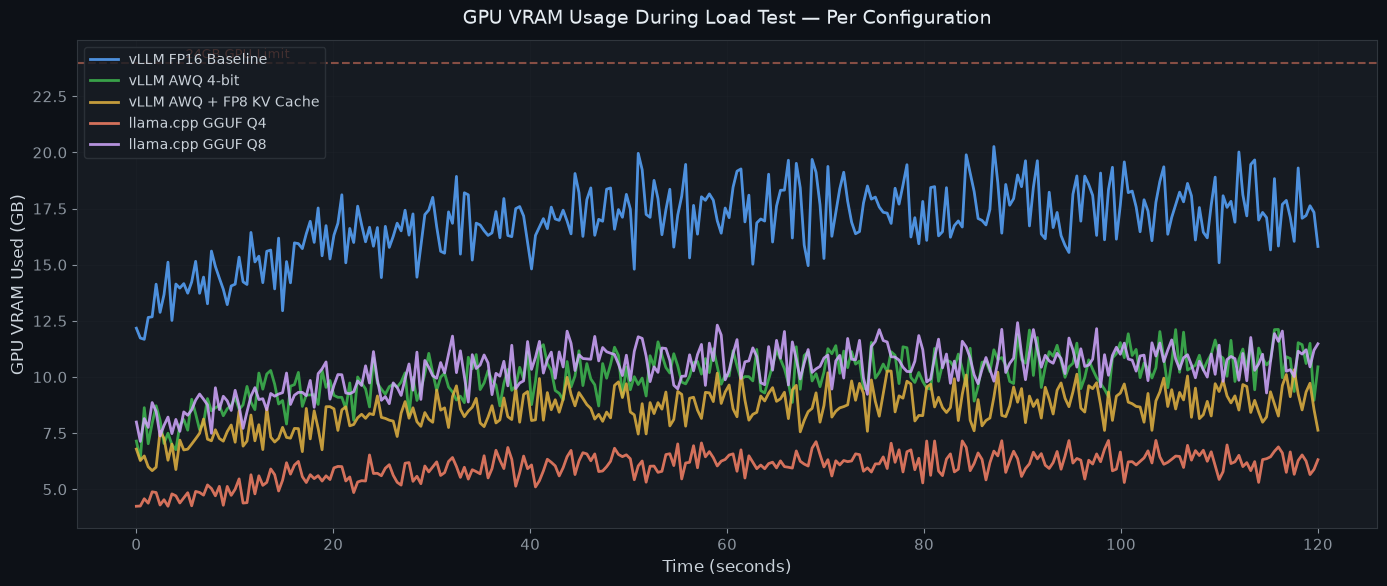

✅ Saved: ..\results\plots/vram_over_time.png


In [13]:
metrics_files = sorted(RESULTS_DIR.glob('metrics_*.csv'))

if not metrics_files:
    print('⚠️  No metrics_*.csv found. Generating synthetic VRAM time-series demo...')
    t = np.linspace(0, 120, 300)
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0d1117')
    
    configs_demo = [
        ('vLLM FP16 Baseline',       18200, 1200, '#58a6ff'),
        ('vLLM AWQ 4-bit',           10800, 800,  '#3fb950'),
        ('vLLM AWQ + FP8 KV Cache',  9200,  700,  '#e3b341'),
        ('llama.cpp GGUF Q4',        6400,  500,  '#f78166'),
        ('llama.cpp GGUF Q8',        11200, 700,  '#d2a8ff'),
    ]
    for label, baseline_mb, noise, color in configs_demo:
        vram = baseline_mb + np.random.normal(0, noise, len(t))
        vram = np.clip(vram, baseline_mb * 0.85, baseline_mb * 1.15)
        # Simulate ramp-up
        ramp = np.exp(-t / 20)
        vram = vram * (1 - ramp * 0.3)
        ax.plot(t, vram / 1024, label=label, linewidth=2, color=color, alpha=0.85)
    
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('GPU VRAM Used (GB)', fontsize=12)
    ax.set_title('GPU VRAM Usage During Load Test — Per Configuration', fontsize=14, pad=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    # 24GB RTX line
    ax.axhline(y=24, color='#f78166', linestyle='--', alpha=0.5, linewidth=1.5, label='24GB VRAM limit')
    ax.annotate('24GB GPU Limit', xy=(5, 24.2), color='#f78166', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'vram_over_time.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f'✅ Saved: {PLOTS_DIR}/vram_over_time.png')
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0d1117')
    for i, mf in enumerate(metrics_files[:6]):  # max 6 files
        mdf = pd.read_csv(mf)
        if 'epoch_s' in mdf.columns and 'gpu_vram_used_mb' in mdf.columns:
            mdf = mdf.dropna(subset=['gpu_vram_used_mb'])
            t_rel = mdf['epoch_s'] - mdf['epoch_s'].min()
            ax.plot(t_rel, mdf['gpu_vram_used_mb'] / 1024, label=mf.stem,
                    linewidth=2, color=CMAP_ACCENT[i % len(CMAP_ACCENT)])
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('VRAM Used (GB)', fontsize=12)
    ax.set_title('GPU VRAM Usage Over Time per Configuration', fontsize=14, pad=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'vram_over_time.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f'✅ Saved: {PLOTS_DIR}/vram_over_time.png')

## Plot 5: Cost/Benefit Summary Table

In [14]:
# ── Plot 5: Cost / Benefit Summary Table ─────────────────────────────────────
from IPython.display import display

# Aggregate: one row per config (mean across profiles)
summary = df.groupby('config_label').agg(
    engine=('engine', 'first'),
    weight_format=('weight_format', 'first'),
    weight_format_label=('weight_format_label', 'first'),
    batch_strategy=('batch_strategy', 'first'),
    throughput_rps=('throughput_rps', 'mean'),
    p50_ms=('p50_latency_ms', 'mean'),
    p95_ms=('p95_latency_ms', 'mean'),
    ttft_ms=('mean_ttft_ms', 'mean'),
    cost_per_1k=('cost_per_1k_requests_usd', 'mean'),
    quality=('composite_quality_score', 'mean'),
    json_acc=('json_accuracy_pct', 'mean'),
    eff_score=('gpu_efficiency_score', 'mean'),
    error_rate=('error_rate_pct', 'mean'),
).reset_index()

# Speedup relative to slowest config (no FP16 baseline assumed)
min_rps = summary['throughput_rps'].min()
min_rps = min_rps if (min_rps and min_rps > 0) else 1.0
summary['speedup'] = (summary['throughput_rps'] / min_rps).round(2)

# Quality % relative to best quality config
max_q = summary['quality'].max()
max_q = max_q if (not pd.isna(max_q) and max_q > 0) else 1.0
summary['quality_vs_best'] = (summary['quality'] / max_q * 100).round(1)

summary_display = summary[[
    'config_label', 'engine', 'weight_format_label',
    'throughput_rps', 'speedup', 'p50_ms', 'p95_ms', 'ttft_ms',
    'cost_per_1k', 'quality_vs_best', 'json_acc', 'error_rate',
]].sort_values('cost_per_1k')

# ── Styled table (Jupyter only) ──────────────────────────────────────────────
try:
    styled = summary_display.rename(columns={
        'config_label':       'Config',
        'engine':             'Engine',
        'weight_format_label':'Weight Format',
        'throughput_rps':     'RPS',
        'speedup':            'Speedup',
        'p50_ms':             'P50 (ms)',
        'p95_ms':             'P95 (ms)',
        'ttft_ms':            'TTFT (ms)',
        'cost_per_1k':        '$/1K Req',
        'quality_vs_best':    'Quality %',
        'json_acc':           'JSON Acc %',
        'error_rate':         'Err %',
    }).style \
      .format({
          'RPS':        '{:.2f}',
          'Speedup':    '{:.2f}x',
          'P50 (ms)':   '{:.0f}',
          'P95 (ms)':   '{:.0f}',
          'TTFT (ms)':  '{:.0f}',
          '$/1K Req':   '${:.6f}',
          'Quality %':  '{:.1f}%',
          'JSON Acc %': '{:.1f}%',
          'Err %':      '{:.1f}%',
      }, na_rep='N/A') \
      .background_gradient(subset=['$/1K Req'],  cmap='RdYlGn_r') \
      .background_gradient(subset=['Quality %'], cmap='RdYlGn') \
      .background_gradient(subset=['RPS'],       cmap='YlGn') \
      .set_table_styles([
          {'selector': 'thead tr th',
           'props': [('background-color','#161b22'),('color','#e6edf3'),
                     ('font-weight','bold'),('border','1px solid #30363d')]},
          {'selector': 'tbody tr td',
           'props': [('background-color','#0d1117'),('color','#c9d1d9'),
                     ('border','1px solid #21262d'),('padding','6px 10px')]},
      ])
    print('Cost/Benefit Summary Table (sorted by $/1K Requests):')
    display(styled)
except Exception as e:
    print(f"Styled display skipped ({e}). Showing plain table:")
    print(summary_display.to_string())

# ── Save as PNG ───────────────────────────────────────────────────────────────
cols_show   = ['config_label', 'engine', 'throughput_rps', 'speedup', 'p95_ms', 'cost_per_1k', 'quality_vs_best', 'error_rate']
col_labels  = ['Config', 'Engine', 'RPS', 'Speedup', 'P95 (ms)', '$/1K Req', 'Quality %', 'Err %']

cell_data = []
for _, row in summary_display.iterrows():
    def fmt(v, spec):
        return spec.format(v) if pd.notna(v) else "N/A"
    cell_data.append([
        str(row.get('config_label', ''))[:32],
        str(row.get('engine', '')),
        fmt(row.get('throughput_rps'), '{:.2f}'),
        fmt(row.get('speedup'), '{:.2f}x'),
        fmt(row.get('p95_ms'), '{:.0f}'),
        fmt(row.get('cost_per_1k'), '${:.6f}'),
        fmt(row.get('quality_vs_best'), '{:.1f}%'),
        fmt(row.get('error_rate'), '{:.1f}%'),
    ])

fig, ax = plt.subplots(figsize=(22, max(4, len(summary_display) * 0.7 + 1.5)))
fig.patch.set_facecolor('#0d1117')
ax.axis('off')

tbl = ax.table(cellText=cell_data, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#161b22' if r == 0 else '#0d1117')
    cell.set_text_props(color='#e6edf3' if r == 0 else '#c9d1d9')
    cell.set_edgecolor('#30363d')

ax.set_title('Cost/Benefit Summary — All Configurations', fontsize=14, pad=16, color='#e6edf3')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'cost_benefit_table.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Saved: {PLOTS_DIR}/cost_benefit_table.png')


KeyError: "['engine'] not in index"

## Summary

All plots saved to `results/plots/`:

| Plot | File | What it shows |
|---|---|---|
| 1 | `pareto_frontier.png` | Cost vs. Throughput Pareto; bubble color=quality, size=P95 latency |
| 2 | `latency_breakdown.png` | P50/P95/P99 bars + TTFT line per configuration |
| 3 | `accuracy_degradation_heatmap.png` | Quality % vs FP16 across weight format × KV cache grid |
| 4 | `vram_over_time.png` | VRAM time-series during load test per configuration |
| 5 | `cost_benefit_table.png` | Full summary table: RPS, speedup, latency, cost, quality |

### Key Observations Template

After running the real benchmark, populate this section:

- **Best cost efficiency**: `___` (\$/1K req)
- **Best throughput**: `___` RPS
- **Minimal quality loss**: `___` (quality drop < 2%)
- **Optimal for production**: `___` (Pareto-dominant configuration)
- **vLLM vs llama.cpp on throughput**: `___x` difference at same weight format